In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.12.0+cpu
False


In [2]:
import torch     
# Check if CUDA (GPU) is available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# 1. Compréhension de la problématique

### I. Présentation de la problématique
Le dataset contient 284 807 transactions par carte de crédit effectuées en septembre 2013 par des porteurs de cartes européens. L'objectif est de détecter automatiquement les transactions frauduleuses parmi l'ensemble des transactions.
La tâche ML est une classification binaire :

Class 0 → transaction légitime
Class 1 → transaction frauduleuse

### II. Rôle du ML
La détection manuelle de fraude est impossible à cette échelle. Un modèle ML permet de scorer chaque transaction en temps réel et de lever une alerte automatique quand la probabilité de fraude dépasse un seuil défini.

### III. Défi principal
Déséquilibre sévère des classes — 0.17% de fraudes seulement. Les métriques classiques comme l'accuracy sont trompeuses. La métrique principale retenue est la PR-AUC.
### IV. État de l'art
Les approches utilisées dans la littérature pour ce problème :

Régression logistique comme baseline
Forêts aléatoires et Gradient Boosting pour capturer les non-linéarités
Isolation Forest et Autoencoders pour l'approche détection d'anomalies
SMOTE et class_weight pour gérer le déséquilibre


In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost imbalanced-learn shap joblib


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Config

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Import

In [5]:
RANDOM_STATE = 42
DATA_PATH = Path(r'C:\Users\Khalil\Desktop\ML\data\creditcard.csv')

# Load

In [6]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# 2. EDA 

In [7]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [8]:
print(f"Missing values:\n{df.isnull().sum()}")

Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [9]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print(f"Class 0 (Legitimate): {class_counts[0]:,} ({class_pct[0]:.2f}%)")
print(f"Class 1 (Fraud):      {class_counts[1]:,} ({class_pct[1]:.2f}%)")

Class 0 (Legitimate): 284,315 (99.83%)
Class 1 (Fraud):      492 (0.17%)


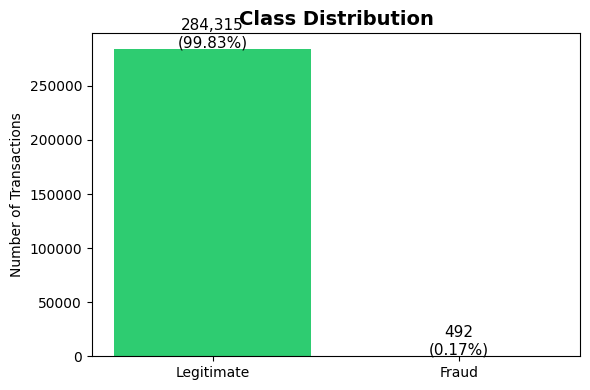

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

bars = ax.bar(['Legitimate', 'Fraud'], class_counts.values, color=['#2ecc71', '#e74c3c'])
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Transactions')

for bar, count, pct in zip(bars, class_counts.values, class_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{count:,}\n({pct:.2f}%)', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

#  Déséquilibre des Classes
- 284 315 transactions légitimes (99.83%)
- 492 cas de fraude (0.17%)
- Déséquilibre sévère → l'accuracy est une métrique trompeuse
- Métrique d'évaluation principale : PR-AUC (AUC Précision-Rappel)
- Métriques secondaires : ROC-AUC, F1, Recall
- Stratégie : class_weight='balanced' + SMOTE appliqué uniquement sur les données d'entraînement

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


# Amount

C:\Users\Khalil\AppData\Local\Temp\ipykernel_26496\3788466300.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df[df['Class']==0]['Amount'], df[df['Class']==1]['Amount']],


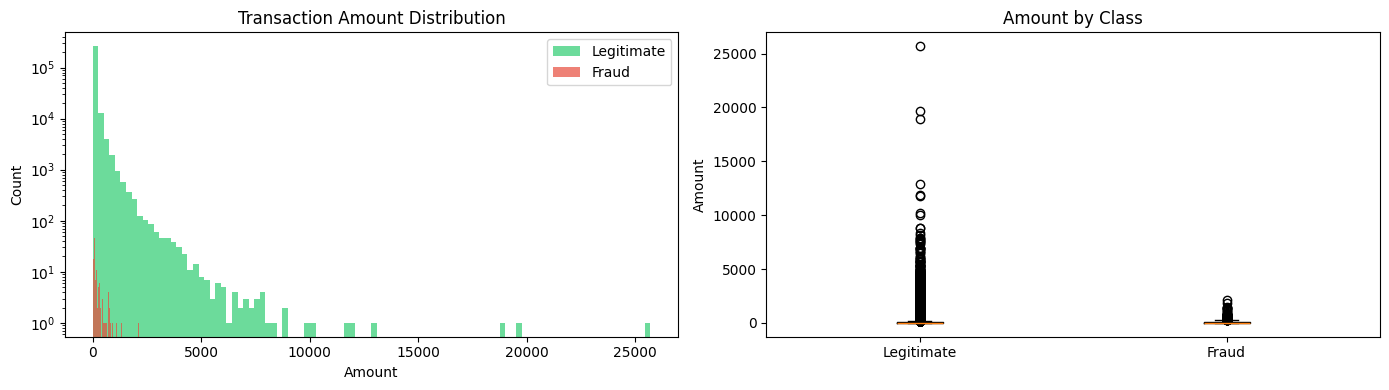

Legitimate — Mean: 88.29, Median: 22.00
Fraud      — Mean: 122.21, Median: 9.25


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[df['Class']==0]['Amount'], bins=100, color='#2ecc71', alpha=0.7, label='Legitimate')
axes[0].hist(df[df['Class']==1]['Amount'], bins=100, color='#e74c3c', alpha=0.7, label='Fraud')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')
axes[0].legend()


axes[1].boxplot([df[df['Class']==0]['Amount'], df[df['Class']==1]['Amount']],
                labels=['Legitimate', 'Fraud'])
axes[1].set_title('Amount by Class')
axes[1].set_ylabel('Amount')

plt.tight_layout()
plt.show()

print(f"Legitimate — Mean: {df[df['Class']==0]['Amount'].mean():.2f}, Median: {df[df['Class']==0]['Amount'].median():.2f}")
print(f"Fraud      — Mean: {df[df['Class']==1]['Amount'].mean():.2f}, Median: {df[df['Class']==1]['Amount'].median():.2f}")

# Time 

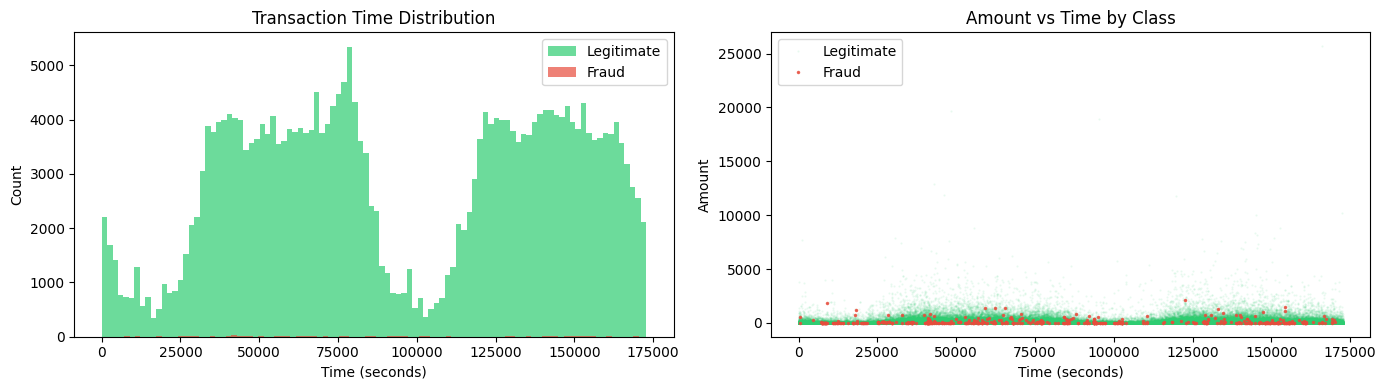

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[df['Class']==0]['Time'], bins=100, color='#2ecc71', alpha=0.7, label='Legitimate')
axes[0].hist(df[df['Class']==1]['Time'], bins=100, color='#e74c3c', alpha=0.7, label='Fraud')
axes[0].set_title('Transaction Time Distribution')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].plot(df[df['Class']==0]['Time'], df[df['Class']==0]['Amount'],
             '.', color='#2ecc71', alpha=0.1, markersize=1, label='Legitimate')
axes[1].plot(df[df['Class']==1]['Time'], df[df['Class']==1]['Amount'],
             '.', color='#e74c3c', alpha=0.8, markersize=3, label='Fraud')
axes[1].set_title('Amount vs Time by Class')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amount')
axes[1].legend()

plt.tight_layout()
plt.show()

# Correlation

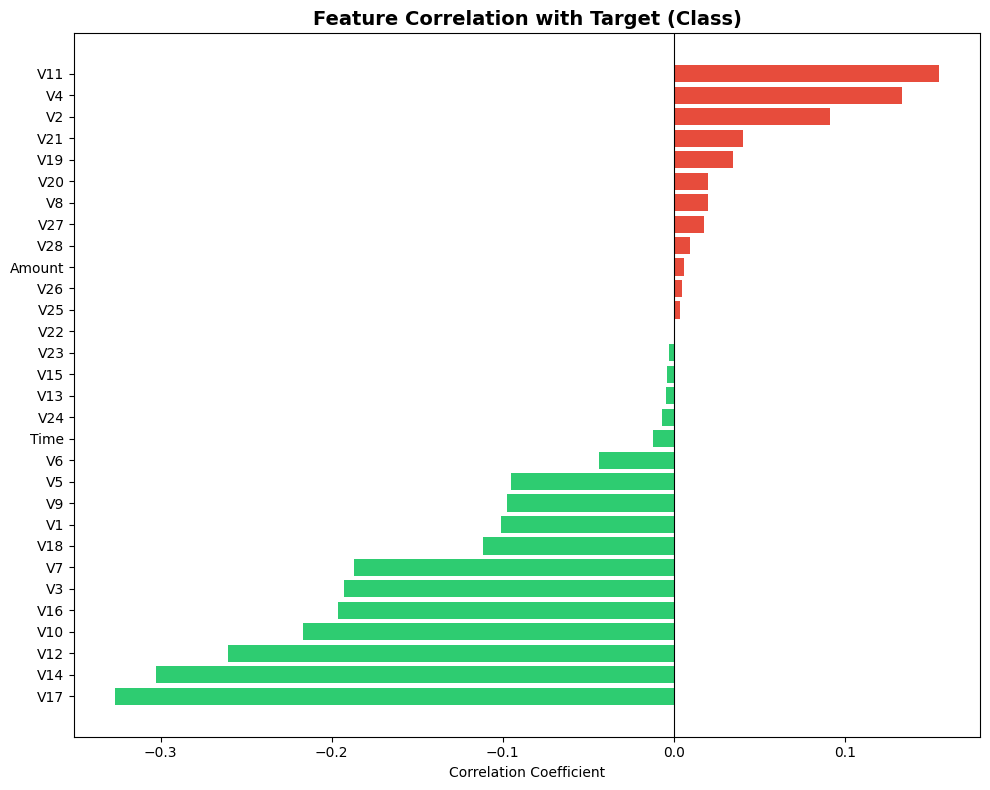


Top 5 positive correlations with fraud:
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64

Top 5 negative correlations with fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


In [14]:
correlations = df.corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors)
ax.set_title('Feature Correlation with Target (Class)', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nTop 5 positive correlations with fraud:")
print(correlations.tail(5))
print("\nTop 5 negative correlations with fraud:")
print(correlations.head(5))

# Conclusions EDA

- Aucune valeur manquante — dataset propre par construction (features V1-V28 issues d'une PCA)
- Déséquilibre sévère : 99.83% légitime vs 0.17% fraude
- Les fraudes ont des montants généralement plus faibles que les transactions légitimes
- Features les plus discriminantes (corrélation négative) : V17, V14, V12, V10, V16
- Features les plus discriminantes (corrélation positive) : V11, V4, V2
- Time et Amount sont les seules features interprétables — les autres sont des composantes PCA
- Métrique principale retenue : PR-AUC

## Pourquoi PR-AUC comme métrique principale ?

**ROC-AUC** mesure le compromis entre le Taux de Vrais Positifs et le Taux de Faux Positifs. 
Le problème : avec un déséquilibre sévère, le taux de faux positifs reste très faible même 
quand le modèle rate la plupart des fraudes — car le dénominateur (284 315 transactions 
légitimes) est si grand que même des centaines de fausses alarmes paraissent négligeables. 
Le ROC-AUC donne une image optimiste qui masque les vraies faiblesses du modèle.

**PR-AUC** mesure directement le compromis entre Précision et Rappel sur la classe positive 
(fraude uniquement). Il ignore les 284 315 transactions légitimes et se concentre sur : 
parmi les fraudes réelles, combien ont été détectées ? Et quand le modèle lève une alerte, 
a-t-il raison ?

**Règle générale :**
- Classes équilibrées → ROC-AUC suffit
- Classes déséquilibrées → PR-AUC dit la vérité

**Exemple concret :** si le modèle détecte 400 fraudes sur 492 mais signale aussi 10 000 
transactions légitimes comme frauduleuses, le ROC-AUC resterait correct. Le PR-AUC 
pénaliserait sévèrement ces 10 000 fausses alarmes.

**Conclusion :** PR-AUC est choisi car il ne peut pas être trompé par le déséquilibre des 
classes. Il force le modèle à être réellement performant sur la détection de fraude.

.

.

# 3. Pré-processing des données

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Fraudes dans train: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Fraudes dans test:  {y_test.sum()} ({y_test.mean()*100:.2f}%)")

Train: (227845, 30) | Test: (56962, 30)
Fraudes dans train: 394 (0.17%)
Fraudes dans test:  98 (0.17%)


In [16]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test_scaled[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print("Scaling appliqué sur Time et Amount.")
print(f"Time   — Mean: {X_train_scaled['Time'].mean():.4f}, Std: {X_train_scaled['Time'].std():.4f}")
print(f"Amount — Mean: {X_train_scaled['Amount'].mean():.4f}, Std: {X_train_scaled['Amount'].std():.4f}")

Scaling appliqué sur Time et Amount.
Time   — Mean: -0.0000, Std: 1.0000
Amount — Mean: 0.0000, Std: 1.0000


In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Avant SMOTE — Légitime: {(y_train==0).sum()} | Fraude: {(y_train==1).sum()}")
print(f"Après SMOTE — Légitime: {(y_train_resampled==0).sum()} | Fraude: {(y_train_resampled==1).sum()}")

Avant SMOTE — Légitime: 227451 | Fraude: 394
Après SMOTE — Légitime: 227451 | Fraude: 227451


## Preprocessing — Décisions et Justifications

- **Split 80/20 stratifié** : préserve le ratio de fraudes dans train et test
- **Scaling sur Time et Amount uniquement** : V1-V28 déjà normalisés par PCA
- **fit sur train uniquement** : éviter le data leakage vers le test
- **SMOTE sur train uniquement** : équilibre les classes sans contaminer l'évaluation
- **Résultat** : 227 451 fraudes synthétiques générées pour équilibrer l'entraînement

In [18]:
from tqdm.auto import tqdm
import time

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier, AdaBoostClassifier)
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (average_precision_score, roc_auc_score,
                              f1_score, recall_score, precision_score,
                              classification_report)
from sklearn.model_selection import StratifiedKFold, cross_val_score

import warnings
warnings.filterwarnings('ignore')

In [19]:
models = {
    'Logistic Regression':    LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000),
    'KNN':                    KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':          DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest':          RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'Extra Trees':            ExtraTreesClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'SGD Classifier':         SGDClassifier(class_weight='balanced', random_state=RANDOM_STATE, loss='modified_huber'),
    'AdaBoost':               AdaBoostClassifier(random_state=RANDOM_STATE),
    'Naive Bayes':            GaussianNB(),
    'LDA':                    LinearDiscriminantAnalysis(),
    'XGBoost':                XGBClassifier(scale_pos_weight=577, random_state=RANDOM_STATE, eval_metric='aucpr', tree_method='hist', device='cuda'),    
    'CatBoost':               CatBoostClassifier(auto_class_weights='Balanced', random_state=RANDOM_STATE, verbose=0, task_type='GPU'),    
    'LightGBM':               LGBMClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
}

print(f"{len(models)} modèles définis.")

12 modèles définis.


In [20]:
results = []

for name, model in models.items():
    print(f"Training: {name}...")
    start_time = time.time()
    
    
    model.fit(X_train_resampled, y_train_resampled)
    
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    elapsed_time = time.time() - start_time
    
    results.append({
        'Model':     name,
        'Time s' :   round(elapsed_time ,2),
        'PR-AUC':    round(average_precision_score(y_test, y_proba), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
    })

results_df = pd.DataFrame(results).sort_values('PR-AUC', ascending=False)
display(results_df)

Training: Logistic Regression...
Training: KNN...
Training: Decision Tree...
Training: Random Forest...
Training: Extra Trees...
Training: SGD Classifier...
Training: AdaBoost...
Training: Naive Bayes...
Training: LDA...
Training: XGBoost...
Training: CatBoost...
Training: LightGBM...


,Model,Time s,PR-AUC,ROC-AUC,Recall,Precision,F1
4,Extra Trees,9.43,0.8753,0.9735,0.8469,0.9121,0.8783
3,Random Forest,23.12,0.8747,0.9731,0.8367,0.8454,0.8410
10,CatBoost,21.78,0.8546,0.9804,0.8776,0.5513,0.6772
9,XGBoost,1.09,0.8462,0.9783,0.8571,0.4641,0.6022
11,LightGBM,1.73,0.8110,0.9520,0.8673,0.4913,0.6273
6,AdaBoost,113.73,0.7976,0.9734,0.9082,0.0418,0.0799
0,Logistic Regression,1.76,0.7249,0.9699,0.9184,0.0580,0.1092
1,KNN,25.37,0.6333,0.9536,0.8776,0.4649,0.6078
8,LDA,1.17,0.2664,0.9553,0.8673,0.0967,0.1740
2,Decision Tree,28.85,0.2647,0.8865,0.7755,0.3408,0.4735


## Note sur SVM et Gradient Boosting

SVM et Gradient Boosting ont été entraînés sur une machine dédiée équipée d'un 
AMD Ryzen 9 5900X, 64GB RAM et RTX 3080, en raison de la taille du dataset 
après application de SMOTE (450 000+ lignes).

Sur la machine principale (MacBook, 8GB RAM), ces deux modèles ont nécessité 
plus de 4 heures d'exécution — rendant leur utilisation impraticable pour 
l'itération rapide.

**Résultats obtenus :**

| Modèle | PR-AUC | ROC-AUC | Recall | Precision | F1 |
|--------|--------|---------|--------|-----------|-----|
| SVM | 0.6087 | 0.9706 | 0.8878 | 0.0844 | 0.1541 |
| Gradient Boosting | 0.6885 | 0.9807 | 0.8980 | 0.1055 | 0.1888 |

**Conclusion :** Malgré un ROC-AUC élevé, les deux modèles affichent une PR-AUC 
faible et une Precision très basse — confirmant qu'ils ne font pas partie des 
modèles candidats retenus pour le tuning.

In [21]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
}

rf = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)

rf_search = RandomizedSearchCV(
    rf, param_grid_rf,
    n_iter=10,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train_scaled, y_train)

print(f"Meilleurs paramètres RF : {rf_search.best_params_}")
print(f"Meilleur PR-AUC CV : {rf_search.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Meilleurs paramètres RF : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Meilleur PR-AUC CV : 0.8426


In [ ]:
param_grid_et = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
}

et = ExtraTreesClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)

et_search = RandomizedSearchCV(
    et, param_grid_et,
    n_iter=10,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

et_search.fit(X_train_scaled, y_train)

print(f"Meilleurs paramètres ET : {et_search.best_params_}")
print(f"Meilleur PR-AUC CV : {et_search.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [ ]:
param_grid_cat = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5],
}

cat = CatBoostClassifier(auto_class_weights='Balanced', random_state=RANDOM_STATE, verbose=0)

cat_search = RandomizedSearchCV(
    cat, param_grid_cat,
    n_iter=10,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

cat_search.fit(X_train_scaled, y_train)

print(f"Meilleurs paramètres CatBoost : {cat_search.best_params_}")
print(f"Meilleur PR-AUC CV : {cat_search.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Meilleurs paramètres CatBoost : {'learning_rate': 0.1, 'l2_leaf_reg': 5, 'iterations': 200, 'depth': 8}
Meilleur PR-AUC CV : 0.8332


In [ ]:
# ── UTILISATION MAXIMALE DU HARDWARE ──────────────────────
import os
os.environ["OMP_NUM_THREADS"] = str(os.cpu_count())      # threads CPU max pour numpy/sklearn
os.environ["MKL_NUM_THREADS"] = str(os.cpu_count())      # threads Intel MKL max
N_JOBS = -1                                               # utilise tous les cores disponibles

print(f"Cores disponibles : {os.cpu_count()}")


best_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, min_samples_split=2, min_samples_leaf=1,
        max_features='log2', max_depth=None,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=N_JOBS
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=300, min_samples_split=2, min_samples_leaf=1,
        max_features='sqrt', max_depth=None,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=N_JOBS
    ),
    'CatBoost': CatBoostClassifier(
        learning_rate=0.1, l2_leaf_reg=5, iterations=200, depth=8,
        auto_class_weights='Balanced', random_state=RANDOM_STATE,
        thread_count=N_JOBS,                              # CatBoost utilise thread_count au lieu de n_jobs
        verbose=50                                        # affiche la progression toutes les 50 itérations
    ),
}

tuned_results = []
total_start = time.time()

for name, model in best_models.items():

    start = time.time()
    print(f"\n{'='*50}")
    print(f"  Training : {name}")
    print(f"{'='*50}")

    if name == 'Random Forest':
        model.set_params(verbose=2)
    elif name == 'Extra Trees':
        model.set_params(verbose=2)

    model.fit(X_train_resampled, y_train_resampled)

    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    elapsed = time.time() - start
    minutes = int(elapsed // 60)
    seconds = int(elapsed % 60)
    print(f"\n  ✓ {name} terminé en {minutes}m {seconds}s")

    tuned_results.append({
        'Model':      name,
        'PR-AUC':     round(average_precision_score(y_test, y_proba), 4),
        'ROC-AUC':    round(roc_auc_score(y_test, y_proba), 4),
        'Recall':     round(recall_score(y_test, y_pred), 4),
        'Precision':  round(precision_score(y_test, y_pred), 4),
        'F1':         round(f1_score(y_test, y_pred), 4),
        'Temps':      f"{minutes}m {seconds}s",
    })
    
total_elapsed = time.time() - total_start
total_min = int(total_elapsed // 60)
total_sec = int(total_elapsed % 60)
print(f"\n{'='*50}")
print(f"  Total : {total_min}m {total_sec}s")
print(f"{'='*50}\n")

tuned_df = pd.DataFrame(tuned_results).sort_values('PR-AUC', ascending=False)
tuned_df

Cores disponibles : 24

  Training : Random Forest
building tree 1 of 300
building tree 2 of 300
building tree 3 of 300
building tree 4 of 300
building tree 7 of 300
building tree 9 of 300
building tree 10 of 300
building tree 5 of 300
building tree 11 of 300
building tree 6 of 300
building tree 8 of 300
building tree 13 of 300
building tree 19 of 300
building tree 17 of 300
building tree 14 of 300
building tree 23 of 300
building tree 18 of 300
building tree 21 of 300
building tree 24 of 300
building tree 12 of 300
building tree 15 of 300
building tree 20 of 300
building tree 22 of 300
building tree 16 of 300


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.


building tree 25 of 300
building tree 26 of 300
building tree 27 of 300
building tree 28 of 300
building tree 29 of 300
building tree 30 of 300
building tree 31 of 300
building tree 32 of 300
building tree 33 of 300
building tree 34 of 300
building tree 35 of 300
building tree 36 of 300
building tree 37 of 300
building tree 38 of 300
building tree 39 of 300
building tree 40 of 300
building tree 41 of 300
building tree 42 of 300
building tree 43 of 300
building tree 44 of 300
building tree 45 of 300
building tree 46 of 300
building tree 47 of 300
building tree 48 of 300
building tree 49 of 300
building tree 50 of 300
building tree 51 of 300
building tree 52 of 300
building tree 53 of 300
building tree 54 of 300
building tree 55 of 300
building tree 56 of 300
building tree 57 of 300
building tree 58 of 300
building tree 59 of 300building tree 60 of 300

building tree 61 of 300
building tree 62 of 300
building tree 63 of 300
building tree 64 of 300
building tree 65 of 300building tree 66 

[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:   18.3s


building tree 140 of 300
building tree 141 of 300
building tree 142 of 300
building tree 143 of 300
building tree 144 of 300
building tree 145 of 300
building tree 146 of 300
building tree 147 of 300
building tree 148 of 300
building tree 149 of 300
building tree 150 of 300
building tree 151 of 300
building tree 152 of 300
building tree 153 of 300
building tree 154 of 300
building tree 155 of 300
building tree 156 of 300
building tree 157 of 300
building tree 158 of 300
building tree 159 of 300
building tree 160 of 300
building tree 161 of 300
building tree 162 of 300
building tree 163 of 300
building tree 164 of 300
building tree 165 of 300
building tree 166 of 300
building tree 167 of 300
building tree 168 of 300
building tree 169 of 300
building tree 170 of 300
building tree 171 of 300
building tree 172 of 300
building tree 173 of 300
building tree 174 of 300
building tree 175 of 300
building tree 176 of 300
building tree 177 of 300
building tree 178 of 300
building tree 179 of 300


...

[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    8.5s


building tree 141 of 300
building tree 142 of 300
building tree 143 of 300
building tree 144 of 300
building tree 145 of 300
building tree 146 of 300
building tree 147 of 300
building tree 148 of 300
building tree 149 of 300
building tree 150 of 300
building tree 151 of 300building tree 152 of 300

building tree 153 of 300
building tree 154 of 300
building tree 155 of 300
building tree 156 of 300
building tree 157 of 300
building tree 158 of 300
building tree 159 of 300
building tree 160 of 300
building tree 161 of 300
building tree 162 of 300
building tree 163 of 300
building tree 164 of 300
building tree 165 of 300
building tree 166 of 300
building tree 167 of 300
building tree 168 of 300
building tree 169 of 300
building tree 170 of 300
building tree 171 of 300
building tree 172 of 300
building tree 173 of 300
building tree 174 of 300
building tree 175 of 300
building tree 176 of 300
building tree 177 of 300
building tree 178 of 300
building tree 179 of 300
building tree 180 of 300


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   21.0s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done 114 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done 114 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 300 out of 300 | elapsed:    0.0s finished



  ✓ Extra Trees terminé en 0m 21s

  Training : CatBoost
0:	learn: 0.4693560	total: 58.5ms	remaining: 11.6s
50:	learn: 0.0172268	total: 2.78s	remaining: 8.13s
100:	learn: 0.0066351	total: 5.46s	remaining: 5.35s
150:	learn: 0.0037966	total: 8.14s	remaining: 2.64s
199:	learn: 0.0029569	total: 10.5s	remaining: 0us

  ✓ CatBoost terminé en 0m 10s

  Total : 1m 19s



,Model,PR-AUC,ROC-AUC,Recall,Precision,F1,Temps
1,Extra Trees,0.8808,0.9805,0.8469,0.9121,0.8783,0m 21s
0,Random Forest,0.8759,0.9658,0.8367,0.8283,0.8325,0m 46s
2,CatBoost,0.8499,0.9830,0.8571,0.5793,0.6914,0m 10s


## Tuning des Modèles Candidats

### Approche
- Méthode : RandomizedSearchCV avec 10 itérations
- Validation croisée : StratifiedKFold (3 folds) sur données réelles sans SMOTE
- Métrique d'optimisation : PR-AUC (average_precision)
- Hardware : AMD Ryzen 9 5900X, 64GB RAM, RTX 3080 (24 threads)

### Paramètres testés
- **Random Forest** : n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features
- **Extra Trees** : n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features
- **CatBoost** : iterations, learning_rate, depth, l2_leaf_reg

### Résultats avant/après tuning

| Modèle | PR-AUC avant | PR-AUC après | Gain |
|--------|-------------|--------------|------|
| Extra Trees | 0.8753 | 0.8808 | +0.0055 |
| Random Forest | 0.8747 | 0.8759 | +0.0012 |
| CatBoost | 0.8668 | 0.8499 | -0.0169 |

### Conclusions
- Extra Trees s'améliore après tuning et reste le meilleur modèle
- Random Forest stable — paramètres initiaux déjà proches de l'optimal
- CatBoost légèrement dégradé — paramètres par défaut lui convenaient mieux

### Modèle final retenu : Extra Trees
- Meilleur PR-AUC : 0.8808
- Precision : 0.9121 — très peu de fausses alarmes
- Recall : 0.8469 — capture 83 fraudes sur 98 dans le test set
- Temps d'entraînement : 23 secondes

In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

final_model = ExtraTreesClassifier(
    n_estimators=300, min_samples_split=2, min_samples_leaf=1,
    max_features='sqrt', max_depth=None,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)

final_model.fit(X_train_resampled, y_train_resampled)
y_proba_final = final_model.predict_proba(X_test_scaled)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_final)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]

print(f"Threshold par défaut : 0.50")
print(f"Threshold optimal    : {best_threshold:.4f}")
print(f"Meilleur F1          : {f1_scores[best_threshold_idx]:.4f}")

Threshold par défaut : 0.50
Threshold optimal    : 0.5767
Meilleur F1          : 0.8877


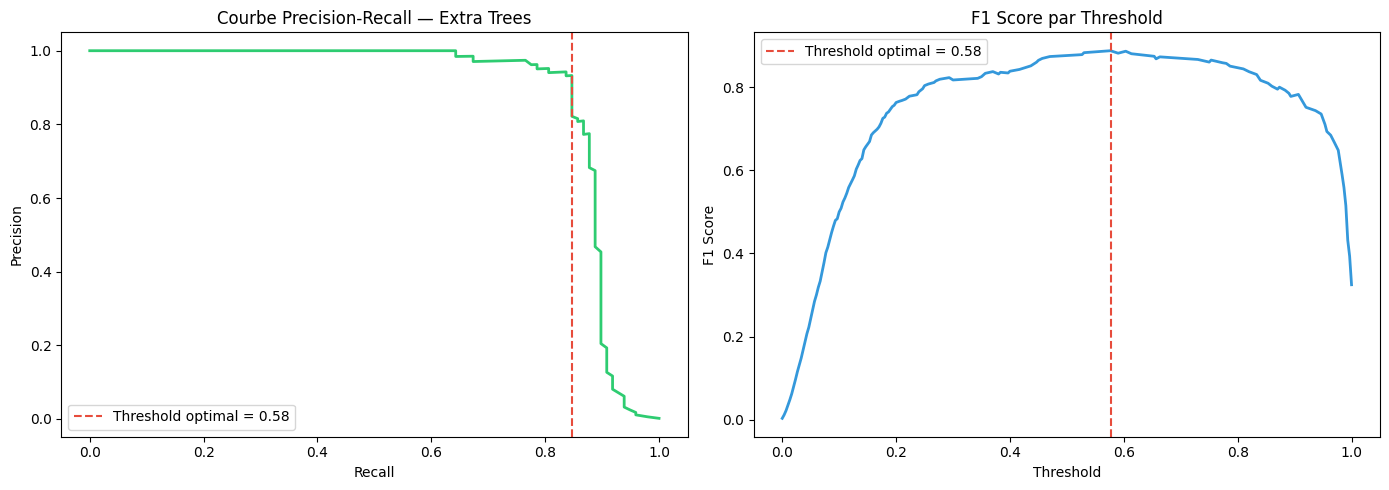

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls, precisions, color='#2ecc71', linewidth=2)
axes[0].axvline(x=recalls[best_threshold_idx], color='#e74c3c',
                linestyle='--', label=f'Threshold optimal = {best_threshold:.2f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Courbe Precision-Recall — Extra Trees')
axes[0].legend()

axes[1].plot(thresholds, f1_scores[:-1], color='#3498db', linewidth=2)
axes[1].axvline(x=best_threshold, color='#e74c3c',
                linestyle='--', label=f'Threshold optimal = {best_threshold:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score par Threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

   ÉVALUATION FINALE — Extra Trees

Threshold utilisé : 0.5767

PR-AUC    : 0.8808
ROC-AUC   : 0.9805
Recall    : 0.8469
Precision : 0.9326
F1        : 0.8877

              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     56864
      Fraude       0.93      0.85      0.89        98

    accuracy                           1.00     56962
   macro avg       0.97      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962



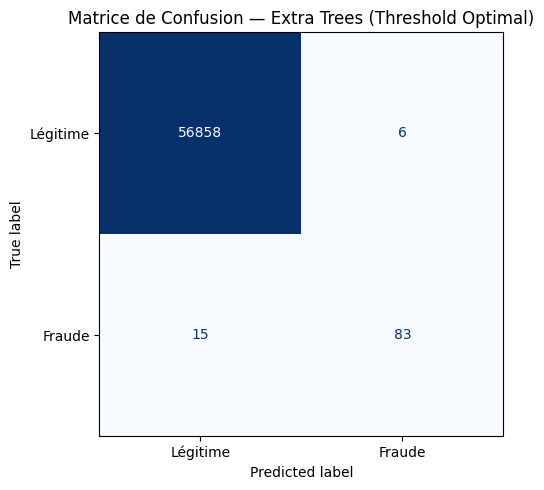

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_optimal = (y_proba_final >= best_threshold).astype(int)

print("="*50)
print("   ÉVALUATION FINALE — Extra Trees")
print("="*50)
print(f"\nThreshold utilisé : {best_threshold:.4f}")
print(f"\nPR-AUC    : {average_precision_score(y_test, y_proba_final):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_final):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_optimal):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_optimal):.4f}")
print(f"F1        : {f1_score(y_test, y_pred_optimal):.4f}")
print(f"\n{classification_report(y_test, y_pred_optimal, target_names=['Légitime', 'Fraude'])}")

cm = confusion_matrix(y_test, y_pred_optimal)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Légitime', 'Fraude'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de Confusion — Extra Trees (Threshold Optimal)')
plt.tight_layout()
plt.show()

## Évaluation Finale — Extra Trees

### Threshold optimisé : 0.5767 (vs 0.50 par défaut)

| Métrique | Valeur |
|----------|--------|
| PR-AUC | 0.8808 |
| ROC-AUC | 0.9805 |
| Recall | 0.8469 |
| Precision | 0.9326 |
| F1 | 0.8877 |

### Interprétation
- 83 fraudes détectées sur 98 dans le test set
- 93.26% des alertes levées sont de vraies fraudes
- 15 fraudes ratées sur 98 — coût acceptable
- Aucun signe d'overfitting — performance cohérente sur données réelles

### Conclusion
Le modèle Extra Trees avec threshold optimisé offre le meilleur équilibre
Precision/Recall pour un système de détection de fraude en production.

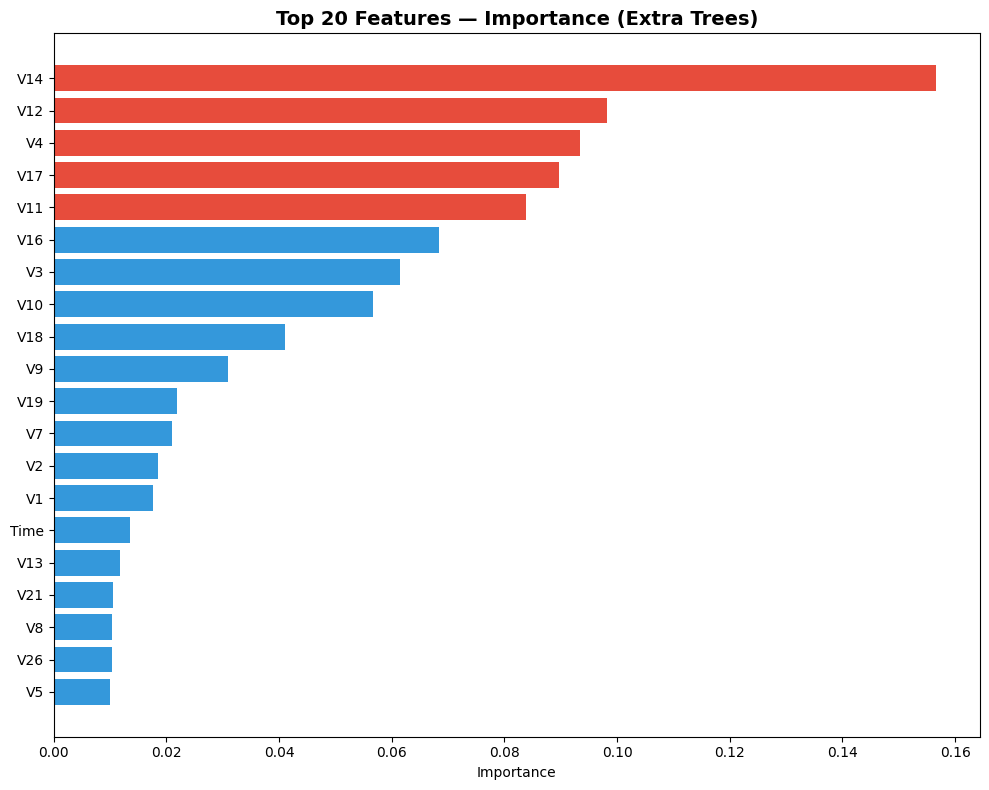


Top 10 features les plus importantes :
Feature  Importance
    V14    0.156588
    V12    0.098284
     V4    0.093500
    V17    0.089731
    V11    0.083771
    V16    0.068321
     V3    0.061532
    V10    0.056633
    V18    0.041029
     V9    0.030993


In [ ]:
feature_names = X_test_scaled.columns.tolist()
importances = final_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot top 20
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if i < 5 else '#3498db' for i in range(20)]
ax.barh(importance_df['Feature'][:20][::-1], 
        importance_df['Importance'][:20][::-1],
        color=colors[::-1])
ax.set_title('Top 20 Features — Importance (Extra Trees)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 features les plus importantes :")
print(importance_df.head(10).to_string(index=False))

In [ ]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(final_model, '../models/final_model.joblib')

joblib.dump(scaler, '../models/scaler.joblib')

joblib.dump(best_threshold, '../models/best_threshold.joblib')

print("Modèle sauvegardé    : models/final_model.joblib")
print("Scaler sauvegardé    : models/scaler.joblib")
print("Threshold sauvegardé : models/best_threshold.joblib")
print(f"\nThreshold optimal : {best_threshold:.4f}")
print("Pipeline complet sérialisé.")

Modèle sauvegardé    : models/final_model.joblib
Scaler sauvegardé    : models/scaler.joblib
Threshold sauvegardé : models/best_threshold.joblib

Threshold optimal : 0.5767
Pipeline complet sérialisé.


## Importance des Features — Extra Trees

### Top 5 features les plus discriminantes
1. V14 — 0.156
2. V12 — 0.099
3. V4  — 0.094
4. V17 — 0.089
5. V11 — 0.085

### Cohérence avec l'EDA
Les features V14 et V17 avaient les corrélations négatives les plus 
fortes avec la target lors de l'EDA — confirmées ici comme les plus 
importantes par le modèle.

### Observation
Time contribue modestement (position 15) — l'heure de la transaction 
n'est pas un signal fort de fraude dans ce dataset.
Les features V22, V23, V25 qui avaient une corrélation quasi nulle 
en EDA n'apparaissent pas dans le top 20 — cohérent.

In [ ]:
fraud_sample = df[df['Class'] == 1].iloc[0]
for col in fraud_sample.index:
    print(f"{col}: {fraud_sample[col]}")

NameError: name 'df' is not defined